In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
index_adjust=0
ocean_fraction=0.25


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(PlottingFunctions, inspect.isfunction)]
# functions

In [31]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5'
# in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_TEST.h5'
with h5py.File(in_file, 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    # W = f['W'][:]
    # QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]
    
#Making Time Matrix
Nt=len(data['time'])
T = np.broadcast_to(np.arange(Nt)[:, None], A_c.shape)  # shape: (Nt, p)

In [32]:
#READING BACK IN
mins_thresh=5
dir3=dir+f'Project_Algorithms/Entrainment/processed_binary_arrays_'+str(mins_thresh)+f'mins_{res}_{Np_str}.h5'
with h5py.File(dir3, 'r') as h5file:
    A_g_Processed = h5file['A_g_Processed'][:]
    A_c_Processed = h5file['A_c_Processed'][:]

In [ ]:
# #DOMAIN SUBSETTING
# ocean_percent=2/8

# left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
# where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
# where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
# end_xh=len(data['xh'])-1-50
# end_xf=len(data['xf'])-1-50

# print(f'x in {0}:{where_coast_xh-1} FOR SEA')
# print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
# # t_end=78 
# # if res=='250m':t_end=410
# # print(f't in {0}:{t_end} (6.5 hours)')
# t_start=36 
# print(f't in {t_start}:end (8 hours)')


# #CORRECTING LAGRANGIAN BINARY ARRAYS
# one=X<where_coast_xh
# two=X>end_xh
# where=np.where(one|two)
# A_g[where]=0
# A_c[where]=0
# # A_g_Processed[where]=0
# # A_c_Processed[where]=0

In [ ]:
###########################################################################################################################################################################

In [ ]:
############## 3D ENTRAINMENT
#RUNNING PROVIDES HORIZONTAL AND VERTICAL CROSS SECTIONS
#ALGORITHM MAINLY USED FOR INDIVIDUAL TRACKED PARCEL (t,z,y,x) CALCULATIONS

In [5]:
# #job array setup
# job_array=True
# if job_array==True:

#     num_jobs=60 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***
#     total_elements=len(data['time']) #total num of variables

#     if num_jobs >= total_elements:
#         raise ValueError("Number of jobs cannot be greater than or equal to total elements.")
    
#     job_range = total_elements // num_jobs  # Base size for each chunk
#     remaining = total_elements % num_jobs   # Number of chunks with 1 extra 
    
#     # Function to compute the start and end for each job_id
#     def get_job_range(job_id):
#         job_id-=1
#         # Add one extra element to the first 'remaining' chunks
#         start_job = job_id * job_range + min(job_id, remaining)
#         end_job = start_job + job_range + (1 if job_id < remaining else 0)
    
#         if job_id == num_jobs - 1: 
#             end_job = total_elements # - 1
#         return start_job, end_job
#     def job_testing():
#         #TESTING
#         start=[];end=[]
#         for job_id in range(1,num_jobs+1):
#             start_job, end_job = get_job_range(job_id)
#             print(start_job,end_job)
#             start.append(start_job)
#             end.append(end_job)
#         print(np.all(start!=end))
#         print(len(np.unique(start))==len(start))
#         print(len(np.unique(end))==len(end))
#     job_testing()
    
#     job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
#     if job_id==0: job_id=1
#     start_job, end_job = get_job_range(job_id)
#     print(f'start_job = {start_job}, end_job = {end_job}')


In [33]:
import numpy as np

def ed3d(A, T, Z, Y, X, type):
    start_time = time.time()
    """
    Function to compute 3D entrainment and update result array based on provided inputs.
    
    Returns a 4D (t,z,y,x) array containing the sum of the D array representing entrained parcels, by 1, and detrained parcels, by -1.
    The finally array is then ordered by the appropiate index using the np.add.at function
    
    Parameters:
    - A: The (t,p) lagrangian binary array.
    - T: The (t,p) lagrangian time index array.
    - Z: The (t,p) Lagrangian z index array.
    - Y: The (t,p) Lagrangian y index array.

    """
    # Compute the difference between neighboring elements along the first axis
    D = np.zeros_like(A)
    D[1:, :] = A[1:, :] - A[:-1, :]
    
    # Update D for entrainment/detrainment
    if type=='e':
        D[D <= 0] = 0
    elif type=='d':
        D[D >= 0] = 0
    
    # Initialize time and vertical dimension arrays
    Nt = len(data['time']); Nz = len(data['zh']); Ny = len(data['yh']); Nx = len(data['xh'])
    
    # Initialize result array
    result = np.zeros((Nt, Nz, Ny, Nx))
    
    # Use np.add.at to accumulate values in the result array
    np.add.at(result, (T, Z, Y, X), D)
    
    end_time = time.time()
    print(f"Execution time: {(end_time - start_time)} seconds")
    return result

In [27]:
# #MEMORY INEFFICIENT VERSION (DON'T RECOMMEND USING)

# #TURN PROCESSING ON OR OFF
# PROCESSING=False
# PROCESSING=True

# if PROCESSING==False:
#     A=A_g
# elif PROCESSING==True:
#     A=A_g_Processed
    
# profile_array_e_g=ed3d(A,T,Z,Y,X,type='e')
# profile_array_d_g=ed3d(A,T,Z,Y,X,type='d')

# if PROCESSING==False:
#     A=A_c
# elif PROCESSING==True:
#     A=A_c_Processed
# profile_array_e_c=ed3d(A,T,Z,Y,X,type='e')
# profile_array_d_c=ed3d(A,T,Z,Y,X,type='d')



# #SAVING
# if PROCESSING==False:
#     dir3=dir+f'Project_Algorithms/Entrainment/3D_entrainmentdetrainment_profiles_{res}_{Np_str}.h5'
# if PROCESSING==True:
#     dir3=dir+f'Project_Algorithms/Entrainment/3D_entrainmentdetrainment_profiles_PREPROCESSING_{res}_{Np_str}.h5'
# with h5py.File(dir3, "w") as h5f:
#     h5f.create_dataset("profile_array_e_g", data=profile_array_e_g)
#     h5f.create_dataset("profile_array_e_c", data=profile_array_e_c)
#     h5f.create_dataset("profile_array_d_g", data=profile_array_d_g)
#     h5f.create_dataset("profile_array_d_c", data=profile_array_d_c)
# print('done')

In [34]:
#MEMORY EFFICIENT VERSION
PROCESSING=False
PROCESSING=True

Nt=len(data['time']);Nz=len(data['zh']);Ny=len(data['yh']);Nx=len(data['xh'])

if PROCESSING == False:
    dir3 = dir + f'Project_Algorithms/Entrainment/3D_entrainmentdetrainment_profiles_{res}_{Np_str}.h5'
elif PROCESSING == True:
    dir3 = dir + f'Project_Algorithms/Entrainment/3D_entrainmentdetrainment_profiles_PREPROCESSING_{res}_{Np_str}.h5'

# Open the HDF5 file for writing and creating datasets
with h5py.File(dir3, "w") as h5f:
    # Pre-create datasets with None for the first dimension (Nt), which will be resized later
    # These are the datasets where you'll store the output of `ed3d` in the future
    h5f.create_dataset("profile_array_e_g", shape=(Nt, Nz, Ny, Nx), maxshape=(Nt, Nz, Ny, Nx), dtype='float32', chunks=True)
    h5f.create_dataset("profile_array_e_c", shape=(Nt, Nz, Ny, Nx), maxshape=(Nt, Nz, Ny, Nx), dtype='float32', chunks=True)
    h5f.create_dataset("profile_array_d_g", shape=(Nt, Nz, Ny, Nx), maxshape=(Nt, Nz, Ny, Nx), dtype='float32', chunks=True)
    h5f.create_dataset("profile_array_d_c", shape=(Nt, Nz, Ny, Nx), maxshape=(Nt, Nz, Ny, Nx), dtype='float32', chunks=True)

print("Arrays pre-created in the HDF5 file.\n")

print('Running\n')
with h5py.File(dir3, "r+") as h5f:  # Use "r+" mode to read and write
    if PROCESSING==False:
        A=A_g
    elif PROCESSING==True:
        A=A_g_Processed
    # Equate 'profile_array_e_g'
    profile_array_e_g = ed3d(A, T, Z, Y, X, type='e')
    h5f["profile_array_e_g"][...] = profile_array_e_g  # Directly overwrite the dataset
    del profile_array_e_g  # Delete the in-memory array after equating
    
    # Equate 'profile_array_d_g'
    profile_array_d_g = ed3d(A, T, Z, Y, X, type='d')
    h5f["profile_array_d_g"][...] = profile_array_d_g  # Directly overwrite the dataset
    del profile_array_d_g  # Delete the in-memory array after equating

    #############################################
    if PROCESSING==False:
        A=A_c
    elif PROCESSING==True:
        A=A_c_Processed
    
    # Equate 'profile_array_e_c'
    profile_array_e_c = ed3d(A, T, Z, Y, X, type='e')
    h5f["profile_array_e_c"][...] = profile_array_e_c  # Directly overwrite the dataset
    del profile_array_e_c  # Delete the in-memory array after equating
    
    # Equate 'profile_array_d_c'
    profile_array_d_c = ed3d(A, T, Z, Y, X, type='d')
    h5f["profile_array_d_c"][...] = profile_array_d_c  # Directly overwrite the dataset
    del profile_array_d_c  # Delete the in-memory array after equating

    print('Arrays have been equated to the HDF5 file.')

Arrays pre-created in the HDF5 file.

Running

Execution time: 24.519904375076294 seconds
Execution time: 22.593413591384888 seconds
Execution time: 22.52034282684326 seconds
Execution time: 22.553483486175537 seconds
Arrays have been equated to the HDF5 file.


In [ ]:
##########################################################################

In [9]:
PROCESSING=False
PROCESSING=True

if PROCESSING==False:
    dir3=dir+f'Project_Algorithms/Entrainment/3D_entrainmentdetrainment_profiles_{res}_{Np_str}.h5'
if PROCESSING==True:
    dir3=dir+f'Project_Algorithms/Entrainment/3D_entrainmentdetrainment_profiles_PREPROCESSING_{res}_{Np_str}.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

In [60]:
# #DOMAIN SUBSETTING
# ocean_percent=2/8

# left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
# where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
# where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
# end_xh=len(data['xh'])-1-50
# end_xf=len(data['xf'])-1-50

# print(f'x in {0}:{where_coast_xh-1} FOR SEA')
# print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
# # t_end=78 
# # if res=='250m':t_end=410
# # print(f't in {0}:{t_end} (6.5 hours)')
# t_start=36 
# print(f't in {t_start}:end (8 hours)')

# profile_array_e_g=profile_array_e_g[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]
# profile_array_d_g=profile_array_d_g[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]
# profile_array_e_c=profile_array_e_c[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]
# profile_array_d_c=profile_array_d_c[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]

In [3]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=(data['xf'][-1].item()-data['xf'][0].item())*1000 #x length (m)
Ly=(data['yf'][-1].item()-data['yf'][0].item())*1000 #y length (m)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len(data['zh'])):
        dz=(zf(k+1)-zf(k))
        for j in range(len(data['yh'])):
            for i in range(len(data['xh'])):
                rho_out=rho(i,j,k,t)
                m+=rho_out*dz
                
    #triple sum
    out=m*dx*dy/Np
    return out

In [6]:
#Calculate Mass Constant
calculate=False
if calculate==True:
    Nt=len(data['time'])
    m_arr=np.zeros((Nt))
    for t in np.arange(Nt):
        print(t)
        m_arr[t]=m(t)
    np.save('Mass_Array.npy', m_arr)
else:
    dir3=dir+f'Project_Algorithms/Entrainment/'
    m_arr = np.load('Mass_Array.npy')

In [10]:

type='general'
type='cloudy'

def apply_constant(profile_array,apply):
    if apply==True:
        Nt=profile_array.shape[0]
        Nz=profile_array.shape[1]
    
        profile_array/=(dx*dy*dt)
        for t in np.arange(Nt):
            profile_array[t]*=m_arr[t]
        for z in np.arange(Nz):
            dz=zf(z+1)-zf(z)
            profile_array[:,z]/=dz
    return profile_array

#APPLY CONSTANTS TO ENTRAINMENT VALUE
##################################################
profile_array_e_g=apply_constant(profile_array_e_g,apply=True)
profile_array_e_c=apply_constant(profile_array_e_c,apply=True)
profile_array_d_g=-apply_constant(profile_array_d_g,apply=True)
profile_array_d_c=-apply_constant(profile_array_d_c,apply=True)
##################################################

if type=='general':
    profile_array_e=profile_array_e_g
    profile_array_d=profile_array_d_g
    profile_array_net=profile_array_e-profile_array_d
if type=='cloudy':
    profile_array_e=profile_array_e_c
    profile_array_d=profile_array_d_c
    profile_array_net=profile_array_e-profile_array_d

Max of profile_array_e: 6.718414806528017e-05
Max of profile_array_d: 1.8360125977778807e-05


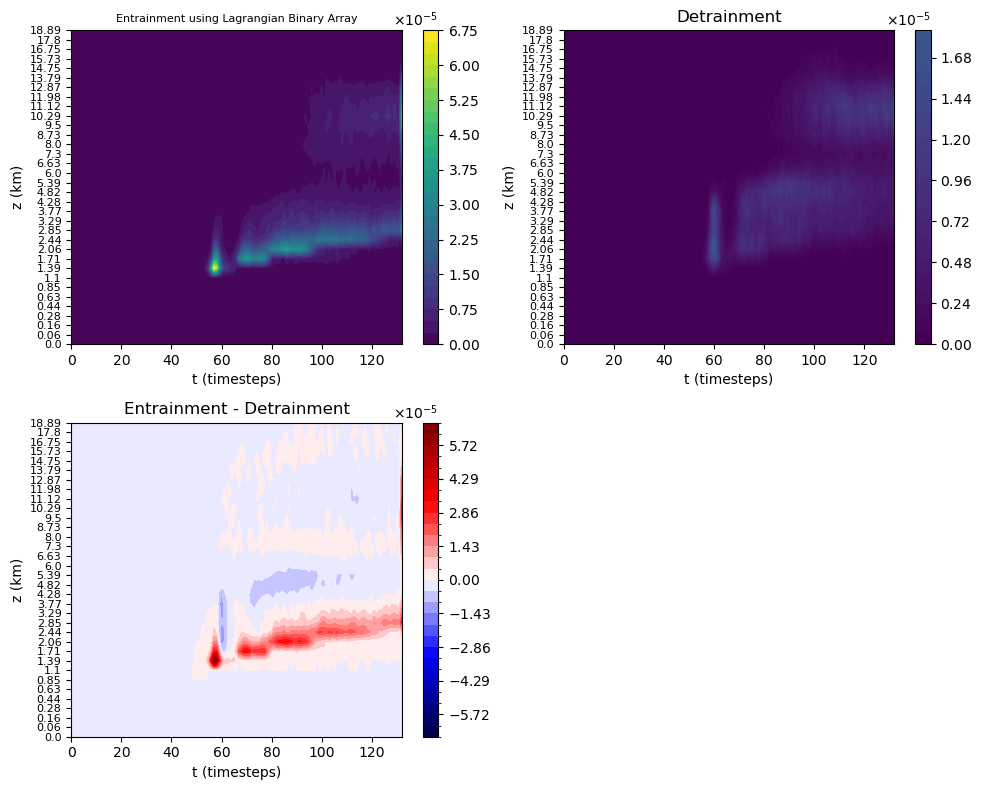

In [11]:
#Entrainment
profile_array_e = np.sum(profile_array_e, axis=(2, 3))*(dy*dx)/(Ly*Lx)
#Detrainment
profile_array_d = np.sum(profile_array_d, axis=(2, 3))*(dy*dx)/(Ly*Lx)
#Net
profile_array_net=np.sum(profile_array_net,axis=(2, 3))*(dy*dx)/(Ly*Lx)

#Plotting
############################################################
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

######
cmap1 = plt.cm.viridis
cmap2 = plt.cm.seismic 
n_levels=29
######

######
vmax_shared = np.max([np.max(profile_array_e), np.max(profile_array_d)])
norm_shared = mcolors.Normalize(vmin=0, vmax=vmax_shared)
######

# First subplot: Entrainment
########################################
ax1 = fig.add_subplot(gs[0, 0])
# contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1)
contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1, norm=norm_shared, levels=n_levels)
cbar1=fig.colorbar(contour1, ax=ax1)
Nz = len(data['zh'])
ax1.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax1.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax1.set_ylabel('z (km)');ax1.set_xlabel('t (timesteps)')
ax1.set_title('Entrainment using Lagrangian Binary Array',fontsize=8)

# Second subplot: Detrainment
########################################
ax2 = fig.add_subplot(gs[0, 1])
# contour2 = ax2.contourf(profile_array_d.T, cmap=cmap1)
contour2 = ax2.contourf(profile_array_d.T, cmap=cmap1, norm=norm_shared, levels=n_levels)
cbar2 = fig.colorbar(contour2, ax=ax2)
ax2.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax2.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax2.set_ylabel('z (km)');ax2.set_xlabel('t (timesteps)')
ax2.set_title('Detrainment')

# Third subplot: Net Entrainment
########################################


# #OLD METHOD, DOESNT BALANCE COLOR LEVELS
# # Normalize with a balanced vmin and vmax
# levels=49; vmin=np.min(profile_array_net);vmax=np.max(profile_array_net)
# # vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
# norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Normalize with a balanced vmin and vmax
vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
levels = np.linspace(vmin, vmax, n_levels)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)
cmap = plt.get_cmap('RdBu_r', n_levels)

ax3 = fig.add_subplot(gs[1, 0])
contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, norm=norm, levels=levels)
# contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, levels=30,vmin=-np.max(abs(profile_array_net)), vmax=+np.max(abs(profile_array_net)))
# cmap2 = plt.get_cmap('RdBu', 29);contour3 = ax3.pcolor(profile_array_net.T, cmap=cmap2, norm=norm, shading='auto')
cbar3 = fig.colorbar(contour3, ax=ax3, norm=norm)

#FIXING TICKS
ax3.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax3.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax3.set_ylabel('z (km)');ax3.set_xlabel('t (timesteps)')
ax3.set_title('Entrainment - Detrainment')

#FIXING SCIENTIFIC NOTATION

def apply_scientific_notation_colorbar(cbars):
    from matplotlib.ticker import ScalarFormatter
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-2, 2))  # Adjust the range for scientific notation
    for cbar in cbars:  # These must be Colorbar instances
        cbar.formatter = formatter
        cbar.update_ticks()
apply_scientific_notation_colorbar([cbar1,cbar2,cbar3])

# Display the plot
plt.tight_layout()

#TESTING
print(f"Max of profile_array_e: {np.max(profile_array_e)}")
print(f"Max of profile_array_d: {np.max(profile_array_d)}")

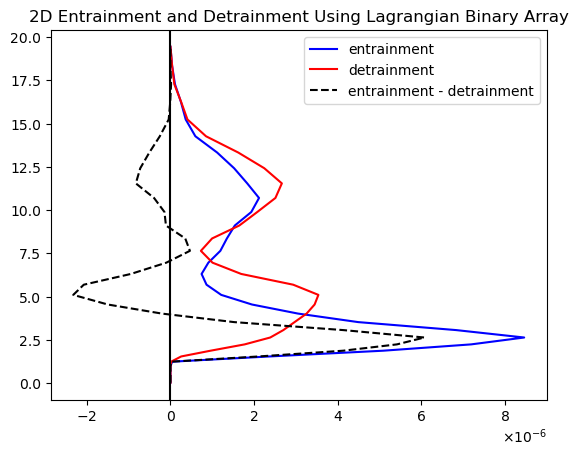

In [12]:
Lt=133*5*60; dt=300
e=np.sum(profile_array_e,axis=(0))*dt/Lt
d=np.sum(profile_array_d,axis=(0))*dt/Lt
net=np.sum(profile_array_e-profile_array_d,axis=(0))*dt/Lt

plt.plot(e,data['zh'],color='blue',label='entrainment')
plt.plot(d,data['zh'],color='red',label='detrainment')
plt.plot(net,data['zh'],linestyle='dashed',color='black',label='entrainment - detrainment')
plt.axvline(0,color='black')

plt.legend(); plt.title('2D Entrainment and Detrainment Using Lagrangian Binary Array')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
plt.gca().xaxis.set_major_formatter(formatter)